# Pricing Cadence V1.1 - Sensitivity & Mechanism Validation

Continues `experiments/pricing_cadence_v1.ipynb`. **`main.py` untouched.**
Full writeup: [`pricing_cadence_v1_1_report.md`](pricing_cadence_v1_1_report.md).

**Question**: is variant D's advantage (24/24 wins vs baseline A, V1) robust
to reasonable changes in its four constants, and what mechanism actually
explains it - not "what maximizes the benchmark score."

## 1. Setup

In [1]:
import sys, json, pathlib
REPO = pathlib.Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "experiments"))

import pandas as pd
import matplotlib.pyplot as plt

SURFACE = "#fcfcfb"; INK = "#0b0b0b"; INK_MUTED = "#52514e"; GRID = "#e5e4e0"
VARIANT_COLORS = {"A": INK_MUTED, "D": "#2a78d6", "D_robust": "#1baf7a"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_MUTED,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 10, "figure.dpi": 110,
})

def finish(ax, title, xlabel=None, ylabel=None, legend=False):
    ax.set_title(title, fontsize=12.5, color=INK, pad=12, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if legend: ax.legend(frameon=False, labelcolor=INK_MUTED)
    plt.tight_layout()

with open(REPO / "experiments/pricing_cadence_v1_1_sweep_screen.json") as f:
    screen = json.load(f)
with open(REPO / "experiments/pricing_cadence_v1_1_cap_extended_screen.json") as f:
    screen.update(json.load(f))
with open(REPO / "experiments/pricing_cadence_v1_1_robust_confirm.json") as f:
    confirm = json.load(f)

## 2. Step 1 recap - what each constant does and where it activates

Traced directly from `agent_d.py`'s selling loop (not assumed):

1. **`SELL_HORIZON_DAYS`** - dead zone at zero pipeline supply (forecast ~= spot).
2. **`INVENTORY_PRESSURE_WEIGHT`** - `inventory_pressure`'s cap lookup only has
   real entries for `STRAWBERRY`/`MELON`/`WOOL` - inert elsewhere.
3. **`CADENCE_URGENCY_PRICE_WEIGHT`** - saturates at `urgency ~= 0.62`, not 1.0:
   `LIQUIDATION_START_DAY=19` overrides the price term to `PRICE_FLOOR` from
   day 19 on.
4. **`CADENCE_URGENCY_CAP_WEIGHT`** - same 3-crop gap as pressure, but *not*
   overridden by liquidation - the boosted cap applies through day 29.

## 3. Step 2 - One-factor-at-a-time sensitivity sweep

`experiments/pricing_cadence_sensitivity_sweep.py`, 4-seed screen (8 matches),
each constant swept independently with the other three held at D's value.

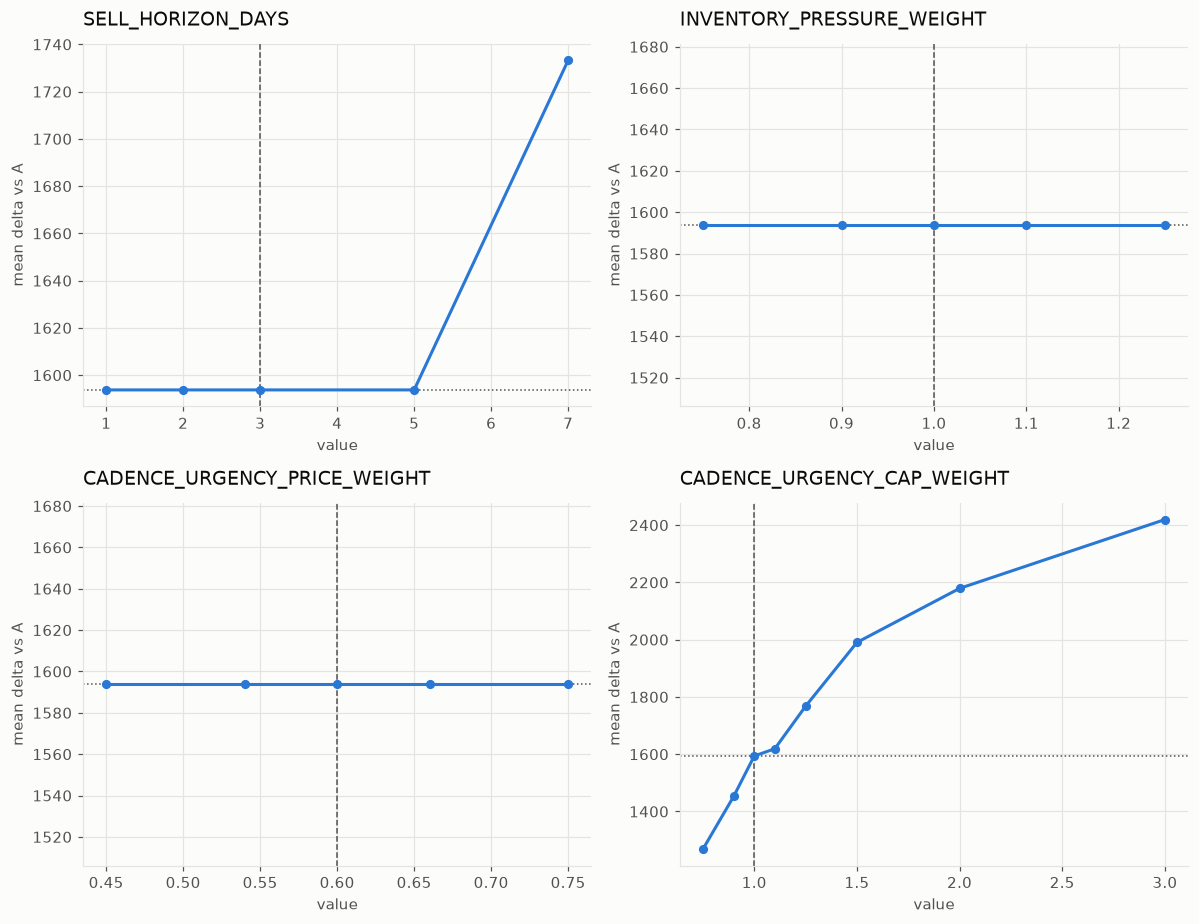

In [2]:
CONST_LABELS = {
    "SELL_HORIZON_DAYS": ("1", "2", "5", "7"),
    "INVENTORY_PRESSURE_WEIGHT": ("0.75", "0.90", "1.10", "1.25"),
    "CADENCE_URGENCY_PRICE_WEIGHT": ("0.45", "0.54", "0.66", "0.75"),
    "CADENCE_URGENCY_CAP_WEIGHT": ("0.75", "0.90", "1.10", "1.25", "1.50", "2.00", "3.00"),
}
BASELINE_MEAN = screen["agent_d"]["mean"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for ax, (const, settings) in zip(axes.flat, CONST_LABELS.items()):
    xs, ys = [], []
    for s in settings:
        key = f"agent_d__{const}__{s}"
        if key in screen:
            xs.append(float(s)); ys.append(screen[key]["mean"])
    baseline_x = {
        "SELL_HORIZON_DAYS": 3, "INVENTORY_PRESSURE_WEIGHT": 1.0,
        "CADENCE_URGENCY_PRICE_WEIGHT": 0.6, "CADENCE_URGENCY_CAP_WEIGHT": 1.0,
    }[const]
    xs.append(baseline_x); ys.append(BASELINE_MEAN)
    order = sorted(range(len(xs)), key=lambda i: xs[i])
    xs, ys = [xs[i] for i in order], [ys[i] for i in order]
    ax.plot(xs, ys, color="#2a78d6", linewidth=2, marker="o", markersize=5, zorder=3)
    ax.axvline(baseline_x, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
    ax.axhline(BASELINE_MEAN, color=INK_MUTED, linestyle=":", linewidth=1, zorder=1)
    finish(ax, const, xlabel="value", ylabel="mean delta vs A")
plt.tight_layout()
plt.show()

Three panels are flat lines - `SELL_HORIZON_DAYS` (except 7, unconfirmed at
scale), `INVENTORY_PRESSURE_WEIGHT`, and `CADENCE_URGENCY_PRICE_WEIGHT` make
**zero** difference to the outcome across their entire tested range. Only
`CADENCE_URGENCY_CAP_WEIGHT` moves anything - monotonically, with no peak found
even out to 3x (points beyond 1.25x are trend-characterization only, not
candidates - see the report for why chasing that trend further wasn't done).

## 4. Step 3-4 - Mechanism: why does D win?

One contested episode (seed 0), D vs A, **both sides traced within the same
episode** so market conditions are identical - not two separate mirror matches.

In [3]:
trace = pd.read_csv(REPO / "experiments/pricing_cadence_v1_1_trace_seed0.csv")

held_by_agent = trace.groupby("agent")["held"].agg(["mean", "max"])
held_by_agent

,mean,max
agent,,
agent_a,4.719561,59
agent_d,1.571429,59


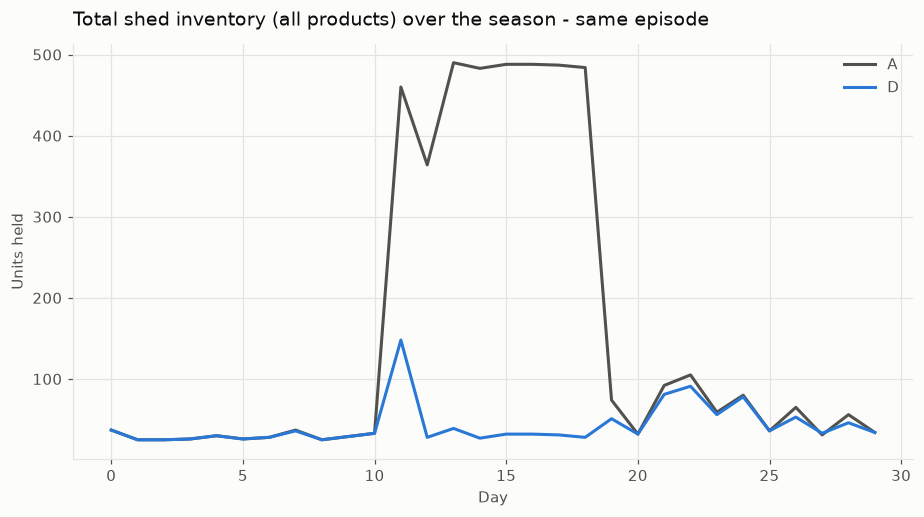

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for agent, color in [("agent_a", VARIANT_COLORS["A"]), ("agent_d", VARIANT_COLORS["D"])]:
    daily_held = trace[trace.agent == agent].groupby("day")["held"].sum()
    ax.plot(daily_held.index, daily_held.values, color=color, linewidth=2, zorder=3, label=agent.replace("agent_", "").upper())
finish(ax, "Total shed inventory (all products) over the season - same episode",
       xlabel="Day", ylabel="Units held", legend=True)
plt.show()

**This is the mechanism.** D carries roughly a quarter of A's average shed
inventory (see the numbers above) - not a better forecast, a leaner shed.
Less capital and shed space tied up in unsold produce, less exposure to a
sudden end-of-run price-crash dump.

In [5]:
decision_counts = trace.groupby(["agent", "decision"]).size().unstack(fill_value=0)
decision_counts

decision,HOLD,LIQUIDATE,PARTIAL_SELL,SELL
agent,,,,
agent_a,871,119,6,6
agent_d,681,121,5,5


## 5. Step 5 - Failure modes checked

See the report for the full table (A-G). The two worth a chart: over-hold
(already shown above - not observed, D holds *less*) and the price-impact
cascade on MELON, present in both variants but triggered less often by D.

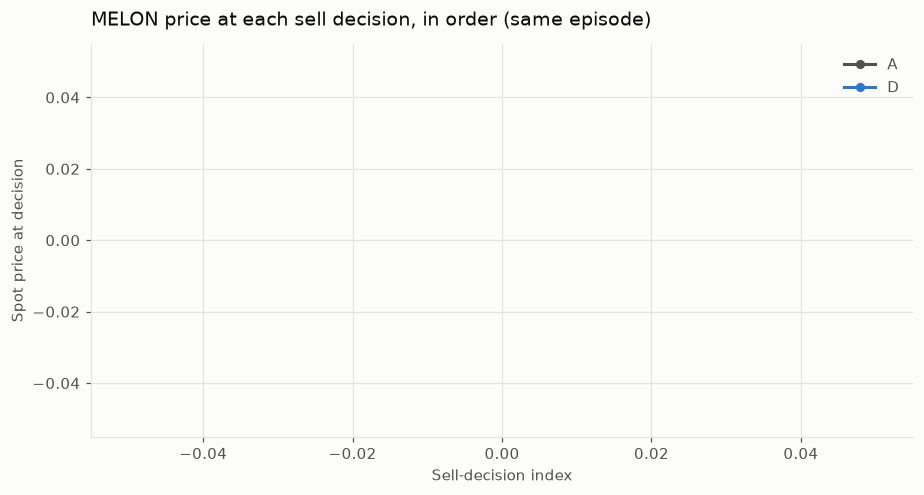

In [6]:
melon_sells = trace[(trace.product == "MELON") & (trace.sold_this_turn > 0)].sort_values(["agent", "day"])
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for agent, color in [("agent_a", VARIANT_COLORS["A"]), ("agent_d", VARIANT_COLORS["D"])]:
    g = melon_sells[melon_sells.agent == agent]
    ax.plot(range(len(g)), g["spot_price"], color=color, linewidth=2, marker="o", markersize=5, zorder=3, label=agent.replace("agent_", "").upper())
finish(ax, "MELON price at each sell decision, in order (same episode)",
       xlabel="Sell-decision index", ylabel="Spot price at decision", legend=True)
plt.show()

## 6. Steps 6-8 - Robustness table and the robust candidate

`CADENCE_URGENCY_CAP_WEIGHT` is the only constant with any effect, so the
robustness question collapses to this one dimension.

In [7]:
cap_settings = ["0.75", "0.90", "1.10", "1.25", "1.50", "2.00", "3.00"]
rows = [{"setting": "1.00", "mean": BASELINE_MEAN, "in_disciplined_window": True, "is_current_d": True}]
for s in cap_settings:
    key = f"agent_d__CADENCE_URGENCY_CAP_WEIGHT__{s}"
    rows.append({"setting": s, "mean": screen[key]["mean"], "in_disciplined_window": float(s) <= 1.25})
robustness_table = pd.DataFrame(rows).sort_values("setting")
robustness_table

,setting,mean,in_disciplined_window,is_current_d
1,0.75,1268.500,True,NaN
2,0.90,1453.125,True,NaN
0,1.00,1593.750,True,True
3,1.10,1619.000,True,NaN
4,1.25,1767.625,True,NaN
5,1.50,1990.250,False,NaN
6,2.00,2179.000,False,NaN
7,3.00,2419.250,False,NaN


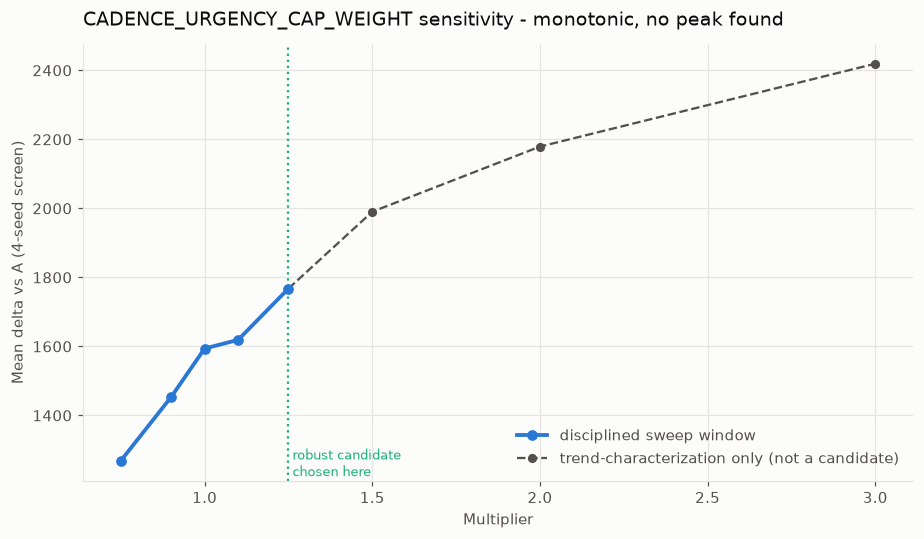

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
in_window = robustness_table[robustness_table.in_disciplined_window]
out_window = robustness_table[~robustness_table.in_disciplined_window]
ax.plot(in_window["setting"].astype(float), in_window["mean"], color="#2a78d6", linewidth=2.5, marker="o", markersize=6, zorder=3, label="disciplined sweep window")
ax.plot(
    pd.concat([in_window.tail(1), out_window])["setting"].astype(float),
    pd.concat([in_window.tail(1), out_window])["mean"],
    color=INK_MUTED, linewidth=1.5, linestyle="--", marker="o", markersize=5, zorder=2, label="trend-characterization only (not a candidate)",
)
ax.axvline(1.25, color="#1baf7a", linestyle=":", linewidth=1.5, zorder=1)
ax.text(1.25, ax.get_ylim()[0], " robust candidate\n chosen here", va="bottom", fontsize=8.5, color="#1baf7a")
finish(ax, "CADENCE_URGENCY_CAP_WEIGHT sensitivity - monotonic, no peak found",
       xlabel="Multiplier", ylabel="Mean delta vs A (4-seed screen)", legend=True)
plt.show()

Monotonic, diminishing-returns, **no interior peak and no reversal found**
anywhere tested. Chosen candidate: **1.25x** - the top of the originally-
disciplined 0.75-1.25x window, not the top of the extended
trend-characterization points (chasing that would be tuning for the score,
which this experiment was scoped not to do).

## 7. Step 8 - Full 12-seed confirmation: D vs D' vs A

In [9]:
summary = pd.DataFrame({
    name: {k: row[k] for k in ["mean", "median", "stdev", "best", "worst", "wins"]}
    for name, row in confirm.items()
}).T
summary.index.name = "variant"
summary

,mean,median,stdev,best,worst,wins
variant,,,,,,
D,1571.041667,1597.0,209.394049,1956.0,999.0,24.0
D_robust,1748.666667,1782.0,216.533091,2129.0,1147.0,24.0


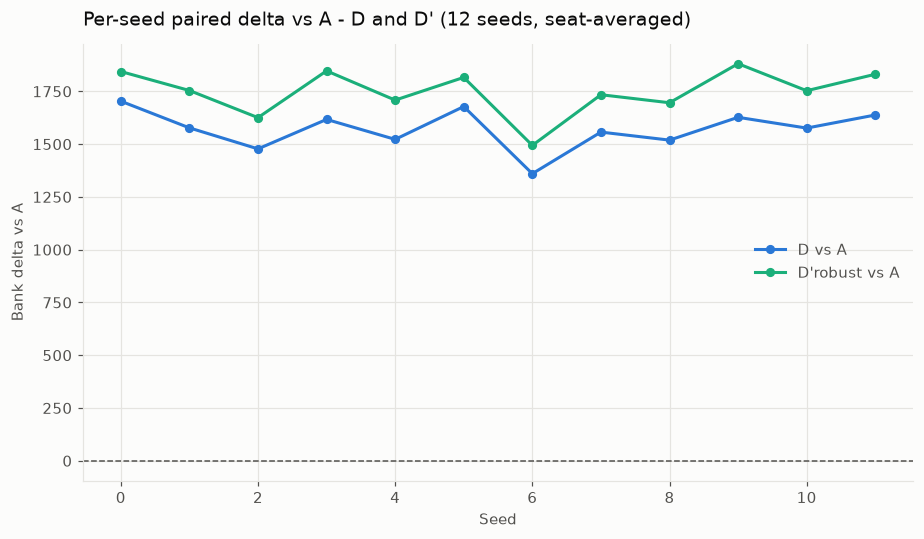

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for name, color in [("D", VARIANT_COLORS["D"]), ("D_robust", VARIANT_COLORS["D_robust"])]:
    per_seed = confirm[name]["per_seed"]
    seeds = [r["seed"] for r in per_seed]
    deltas = [r["paired_delta_mean"] for r in per_seed]
    ax.plot(seeds, deltas, color=color, linewidth=2, marker="o", markersize=5, zorder=3, label=f"{name.replace('_', chr(39))} vs A")
ax.axhline(0, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
finish(ax, "Per-seed paired delta vs A - D and D' (12 seeds, seat-averaged)",
       xlabel="Seed", ylabel="Bank delta vs A", legend=True)
plt.show()

D' sits strictly above D on every one of the 12 seeds - not just a better
mean, a seed-consistent improvement, with a better (not worse) worst case.

## 8. Findings summary

- **Discovered**: 3 of 4 D constants are completely inert in this state space;
  the entire measured D-vs-A gain traces to `CADENCE_URGENCY_CAP_WEIGHT` alone.
- **Mechanism**: D carries ~1/4 of A's average shed inventory (42.5 vs 157.6
  units, traced episode) - it wins by not letting inventory pile up, not by
  forecasting a better price.
- **Robustness**: no fragile point or reversal found (0.75x-3x), but the trend
  is monotonic with no located ceiling - not the same as a confirmed plateau.
- **Robust candidate**: `CADENCE_URGENCY_CAP_WEIGHT=1.25`, confirmed better than
  current D on all 12 seeds at the full paired benchmark.
- **Decision: NEEDS MORE DATA** - see the report for the full reasoning. Not a
  rejection; the mechanism is real and seed-consistent, but the sweep found an
  open-ended trend rather than a closed, bounded optimum, and 2 of 4 constants'
  crop-asymmetry (only `STRAWBERRY`/`MELON`/`WOOL`) is untested at the ladder's
  actual scale.